In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier



In [19]:
df = pd.read_csv("predictive_performance_data.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [21]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [22]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [23]:
# Drop ID columns (no predictive value)
df = df.drop(columns=["UDI", "Product ID"])

# One-hot encode machine type
df = pd.get_dummies(df, columns=["Type"], drop_first=True)
df.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [24]:
X = df[['Air temperature [K]', 
          'Process temperature [K]', 
          'Rotational speed [rpm]', 
          'Torque [Nm]', 
          'Tool wear [min]']]

y = df["Machine failure"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (10000, 5)
Target shape: (10000,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42,stratify=y)


In [26]:
#Scaling ensures all sensor readings contribute equally to the model.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(probability=True, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier()
}


In [28]:
results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall
    })
    
    print(f"\n{model_name}")
    print("Accuracy:", accuracy)
    print("Recall:", recall)



Logistic Regression
Accuracy: 0.821
Recall: 0.8382352941176471

Decision Tree
Accuracy: 0.9755
Recall: 0.5294117647058824

Random Forest
Accuracy: 0.9825
Recall: 0.5588235294117647

Support Vector Machine
Accuracy: 0.913
Recall: 0.9264705882352942

KNN
Accuracy: 0.9755
Recall: 0.3382352941176471


Although Random Forest achieved the highest accuracy, it had lower recall 
for failure detection. In predictive maintenance systems, detecting failures 
is more important than overall accuracy. 

The Support Vector Machine achieved the highest recall score (92.6%), meaning 
it successfully detected most machine failures. Therefore, SVM was selected 
as the final model for deployment.

In [29]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Recall", ascending=False)


,Model,Accuracy,Recall
3,Support Vector Machine,0.9130,0.926471
0,Logistic Regression,0.8210,0.838235
2,Random Forest,0.9825,0.558824
1,Decision Tree,0.9755,0.529412
4,KNN,0.9755,0.338235


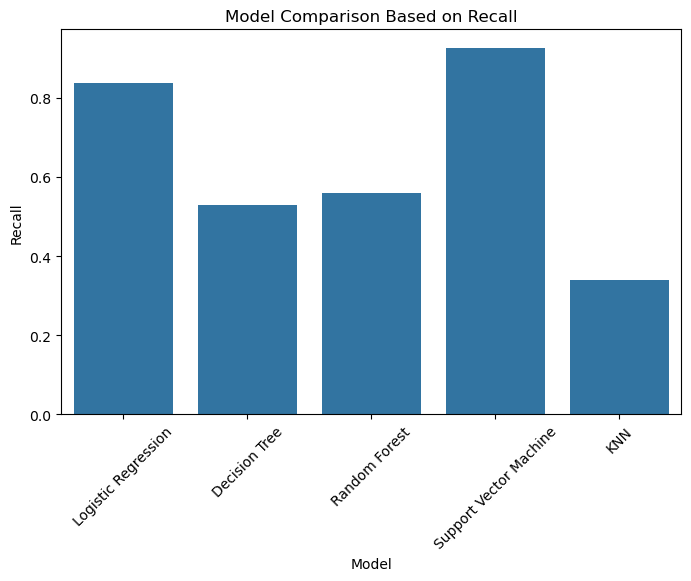

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Recall", data=results_df)
plt.title("Model Comparison Based on Recall")
plt.xticks(rotation=45)
plt.show()


In [31]:
from sklearn.svm import SVC
import pickle

model = SVC(kernel='rbf',probability=True,class_weight='balanced')
model.fit(X_train_scaled, y_train)

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler,open("scaler.pkl","wb"))

print("SVM model saved successfully!")



SVM model saved successfully!


In [32]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
#The model achieved high recall for the failure class, meaning it can successfully detect most machine failures.


Accuracy: 0.913
Recall: 0.9264705882352942

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1932
           1       0.27      0.93      0.42        68

    accuracy                           0.91      2000
   macro avg       0.63      0.92      0.69      2000
weighted avg       0.97      0.91      0.93      2000



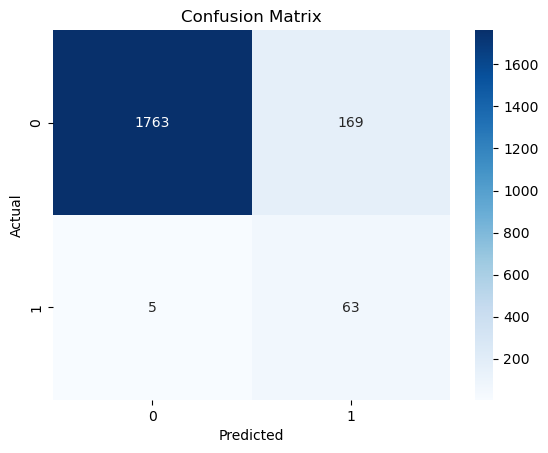

In [33]:
y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

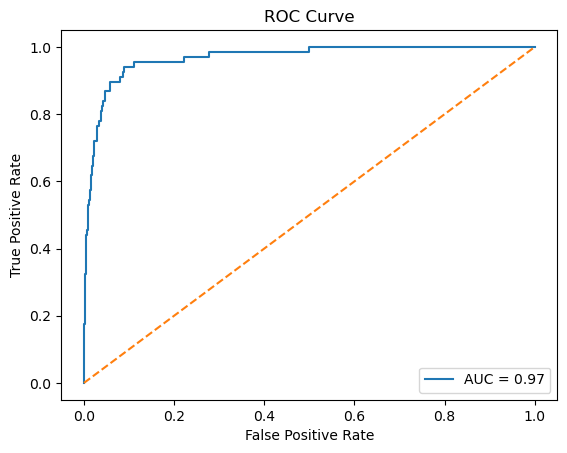

In [34]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

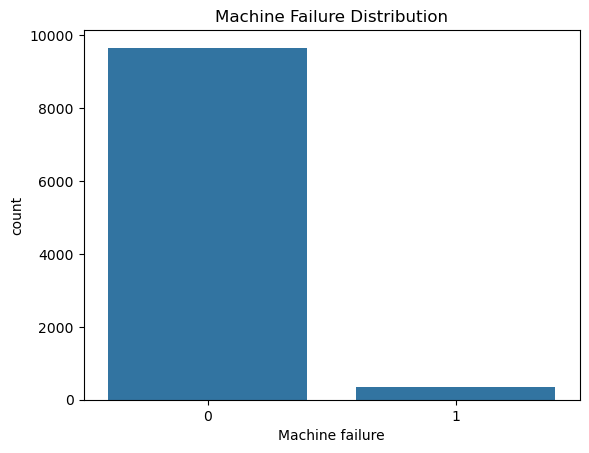

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["Machine failure"])
plt.title("Machine Failure Distribution")
plt.show()
#Most machines operate normally, while only a small portion fails.
#This shows dataset imbalance.

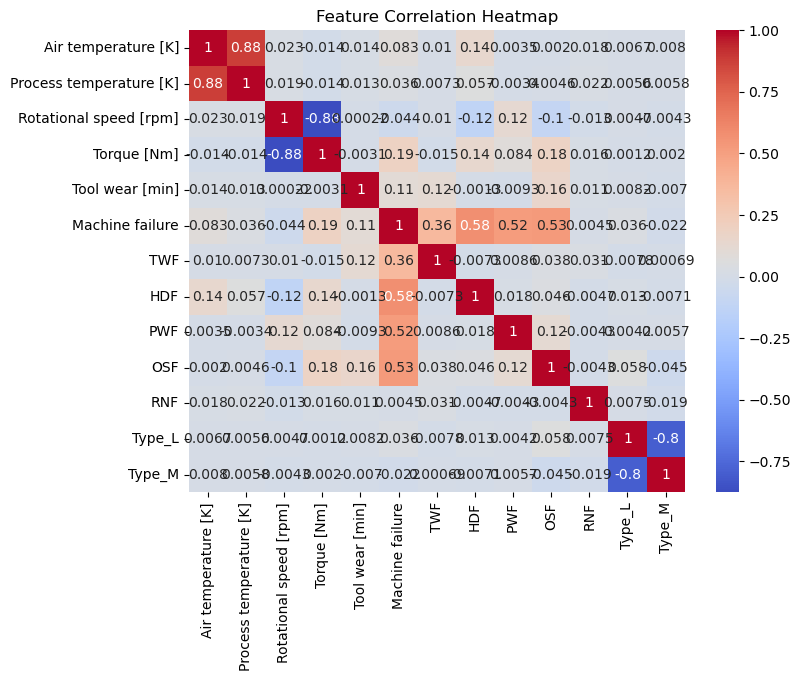

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

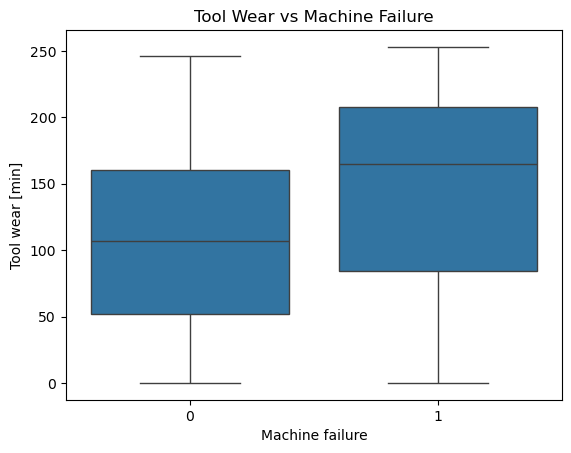

In [37]:
sns.boxplot(x=df["Machine failure"], y=df["Tool wear [min]"])

plt.title("Tool Wear vs Machine Failure")
plt.show()
#Machines with higher tool wear fail more often.

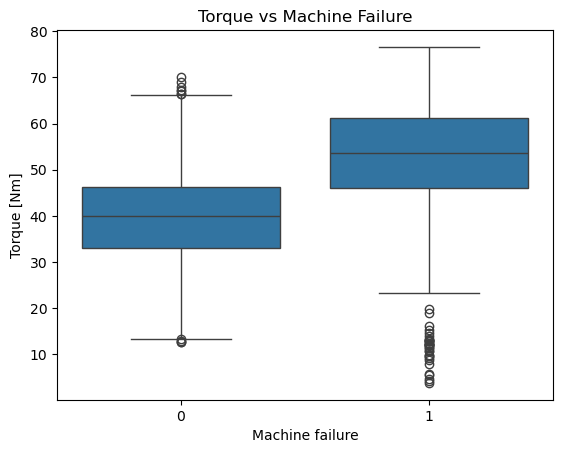

In [38]:
sns.boxplot(x=df["Machine failure"], y=df["Torque [Nm]"])

plt.title("Torque vs Machine Failure")
plt.show()
#Higher torque increases failure probability.

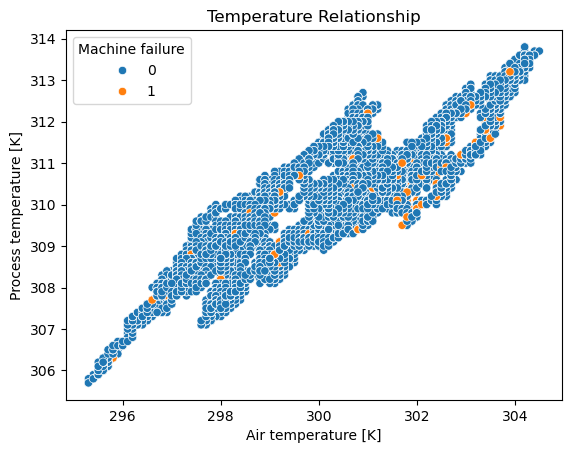

In [39]:
sns.scatterplot(
    x=df["Air temperature [K]"],
    y=df["Process temperature [K]"],
    hue=df["Machine failure"]
)

plt.title("Temperature Relationship")
plt.show()

In [40]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [41]:
import shap
# take small background sample
X_sample = X_train_scaled[:100]

explainer = shap.KernelExplainer(model.predict_proba, X_sample)

shap_values = explainer.shap_values(X_test_scaled[:50])
#SHAP calculations are very slow

  0%|          | 0/50 [00:00<?, ?it/s]

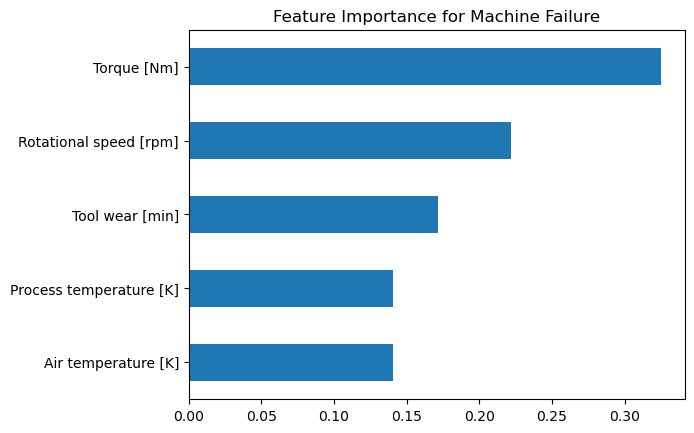

In [42]:
rf = RandomForestClassifier()

rf.fit(X_train_scaled, y_train)

importance = rf.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Machine Failure")

plt.show()

Feature importance analysis shows that torque is the most influential factor 
in predicting machine failure, followed by rotational speed and tool wear. 
This indicates that mechanical stress and operational load play a major role 
in machine breakdowns, while temperature variables have relatively smaller impact.